In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
user_home = os.environ['HOME']
print(user_home)




/home/dejuns


In [3]:
save_dir = Path(f'{user_home}/git/stoic2021/data/STOIC2021Round1')
info_fp = save_dir/f'stoic2021_case_info_split.csv'
info_tb = pd.read_csv(info_fp)
info_tb.set_index('PatientID', inplace=True)
print(info_tb.describe())
print(info_tb.columns)


         probCOVID  probSevere  SliceThickness        split
count  2000.000000  2000.00000     2000.000000  2000.000000
mean      0.602500     0.15050        1.092200     2.000000
std       0.489503     0.35765        0.502086     1.414567
min       0.000000     0.00000        0.500000     0.000000
25%       0.000000     0.00000        0.750000     1.000000
50%       1.000000     0.00000        1.000000     2.000000
75%       1.000000     0.00000        1.250000     3.000000
max       1.000000     1.00000        5.000000     4.000000
Index(['probCOVID', 'probSevere', 'ITK_InputFilterName',
       'ITK_original_direction', 'ITK_original_spacing', 'PatientAge',
       'PatientName', 'PatientSex', 'SliceThickness', 'img_path', 'old_shape',
       'old_spacing', 'resize_shape', 'new_shape', 'new_spacing',
       'body_center', 'split'],
      dtype='object')


In [4]:
std_age = lambda x: int(x[1:-1]) if len(x) > 2 else int(x)
info_tb['PatientAge'] = info_tb['PatientAge'].apply(std_age)

probCOVID     0    1
PatientAge          
35          146   99
45           80  150
55          121  225
65          119  266
75          132  223
85          197  242


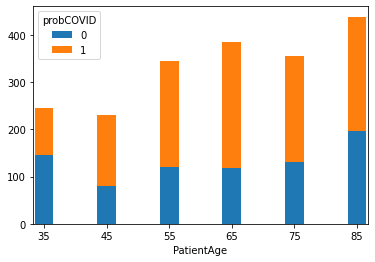

In [5]:
covid_by_age = pd.crosstab(info_tb['PatientAge'], info_tb['probCOVID'])
print(covid_by_age)
ax_age = covid_by_age.plot.bar(rot = 0, stacked = True, width=3)


probSevere    0   1
PatientAge         
35          236   9
45          205  25
55          309  37
65          317  68
75          281  74
85          351  88


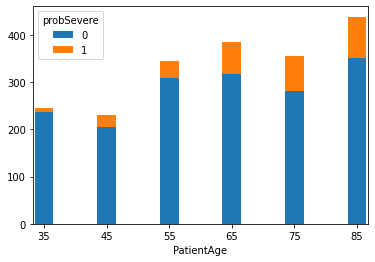

In [6]:

severe_by_age = pd.crosstab(info_tb['PatientAge'], info_tb['probSevere'])
print(severe_by_age)
ax_severe = severe_by_age.plot.bar(rot = 0, stacked = True, width=3)

probSevere    0    1
PatientSex          
A             1    0
F           701   91
M           858  192
O           106   13


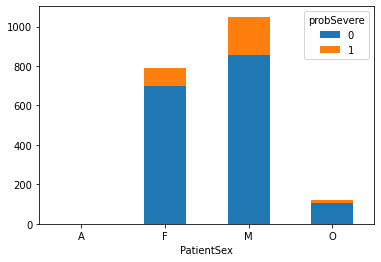

In [7]:

severe_by_sex = pd.crosstab(info_tb['PatientSex'], info_tb['probSevere'])
print(severe_by_sex)
ax_severe = severe_by_sex.plot.bar(rot = 0, stacked = True)

probCOVID     0    1
PatientSex          
A             1    0
F           330  462
M           372  678
O            77   42


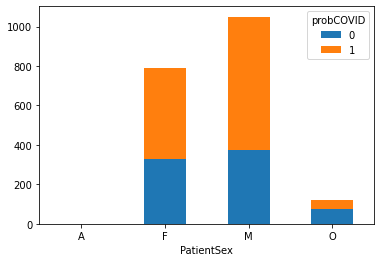

In [8]:
covid_by_sex = pd.crosstab(info_tb['PatientSex'], info_tb['probCOVID'])
print(covid_by_sex)
ax_severe = covid_by_sex.plot.bar(rot = 0, stacked = True)

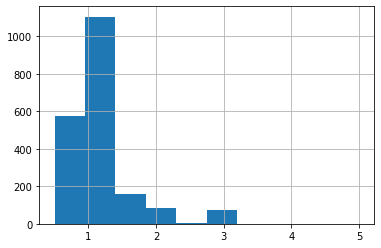

In [9]:
thick_ax = info_tb['SliceThickness'].hist()

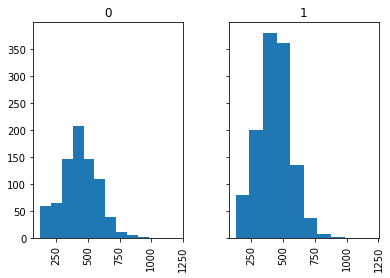

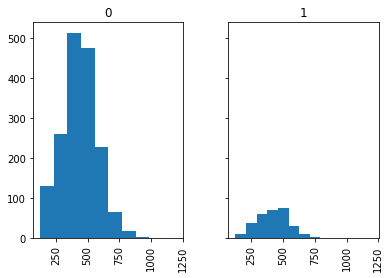

In [10]:
info_tb['old_shape_z'] = info_tb['old_shape'].apply(lambda x: int(x.split('_')[-1]))
ax_zsize = info_tb.hist('old_shape_z',  by = 'probCOVID', sharex = True, sharey = True)

ax_zsize_severe = info_tb.hist('old_shape_z',  by = 'probSevere', sharex = True, sharey = True)


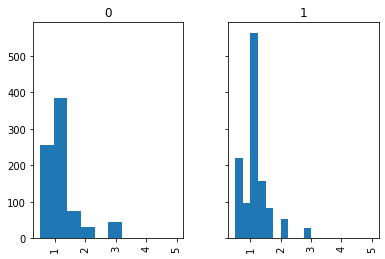

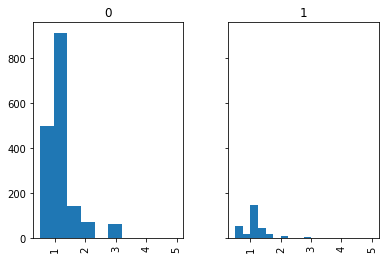

In [11]:
# info_tb.plot.scatter(x = 'SliceThickness', y = 'old_shape_z')
ax_zsize = info_tb.hist('SliceThickness',  by = 'probCOVID', sharex = True, sharey = True)

ax_zsize_severe = info_tb.hist('SliceThickness',  by = 'probSevere', sharex = True, sharey = True)

probCOVID         0    1
SliceThickness          
0.500             3    2
0.600            22   10
0.625           125  209
0.750           103   98
0.900             3    0
1.000           314  563
1.250            71  157
1.500            76   84
2.000            30   52
2.500             2    1
3.000            45   29
5.000             1    0


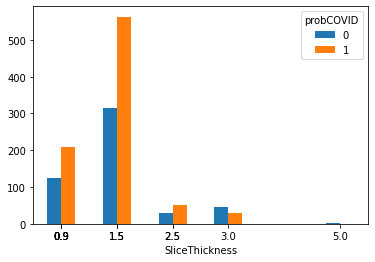

In [12]:
covid_by_thick = pd.crosstab(info_tb['SliceThickness'], info_tb['probCOVID'])
print(covid_by_thick)
ax_thick = covid_by_thick.plot.bar(rot = 0,)

probSevere        0    1
SliceThickness          
0.500             4    1
0.600            31    1
0.625           280   54
0.750           183   18
0.900             3    0
1.000           730  147
1.250           183   45
1.500           142   18
2.000            73    9
2.500             3    0
3.000            66    8
5.000             1    0


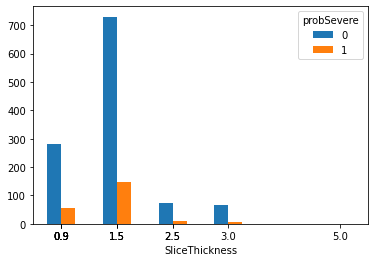

In [13]:
severe_by_thick = pd.crosstab(info_tb['SliceThickness'], info_tb['probSevere'])
print(severe_by_thick)
ax_thick = severe_by_thick.plot.bar(rot = 0,)

<AxesSubplot:xlabel='new_spacing_z', ylabel='new_shape_z'>

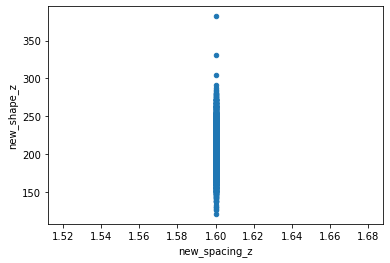

In [14]:
# 'new_shape', 'new_spacing',
info_tb['new_shape_z'] = info_tb['new_shape'].apply(lambda x: int(x.split('_')[-1]))
info_tb['new_spacing_z'] = info_tb['new_spacing'].apply(lambda x: float(x.split('_')[-1]))
info_tb.plot.scatter(x = 'new_spacing_z', y = 'new_shape_z')